# Bank Marketing Campaign Analysis

This analysis focuses on understanding the success of marketing campaigns for a Portuguese banking institution. The goal is to predict whether a client will subscribe to a term deposit based on direct marketing campaign data.

**Dataset:** [Bank Marketing Dataset](https://www.kaggle.com/janiobachmann/bank-marketing-dataset)
**Source:** Kaggle

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import shutil
import os

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Data Loading and Inspection

In [14]:
# Download the dataset
path = kagglehub.dataset_download("janiobachmann/bank-marketing-dataset")
print("Path to dataset files:", path)

# Locate the csv file
csv_file = os.path.join(path, "bank.csv")

# Copy to current directory
if os.path.exists(csv_file):
    shutil.copy(csv_file, "bank.csv")
    print("Copied bank.csv to current directory")
else:
    print("bank.csv not found in download path")

Path to dataset files: /home/rawwa/.cache/kagglehub/datasets/janiobachmann/bank-marketing-dataset/versions/1
Copied bank.csv to current directory


In [15]:
df = pd.read_csv("bank.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB


## 2. Data Cleaning
Checking for missing values and duplicates.

In [17]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Missing values:
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Duplicates: 0


In [18]:
# Remove duplicates if any
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print("Duplicates removed. New shape:", df.shape)

## 3. Exploratory Data Analysis (EDA)

/tmp/ipykernel_34892/4123462981.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='deposit', data=df, palette='viridis')


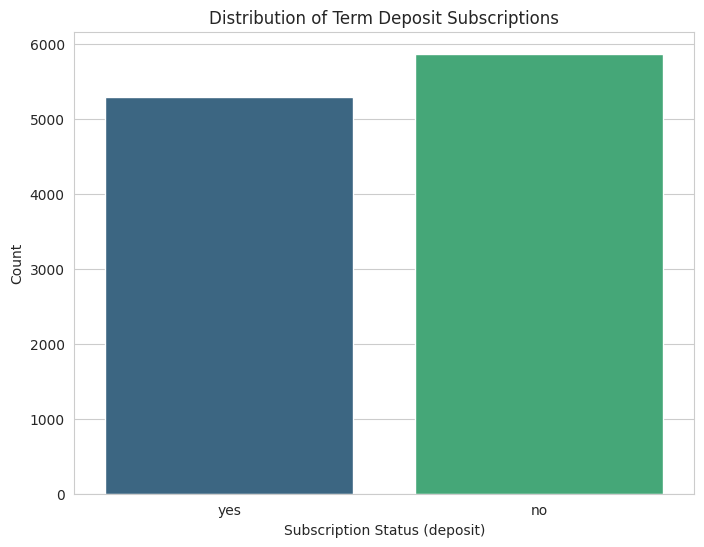

In [19]:
# Target Variable Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='deposit', data=df, palette='viridis')
plt.title('Distribution of Term Deposit Subscriptions')
plt.xlabel('Subscription Status (deposit)')
plt.ylabel('Count')
plt.savefig('images/target_dist.png')
plt.show()

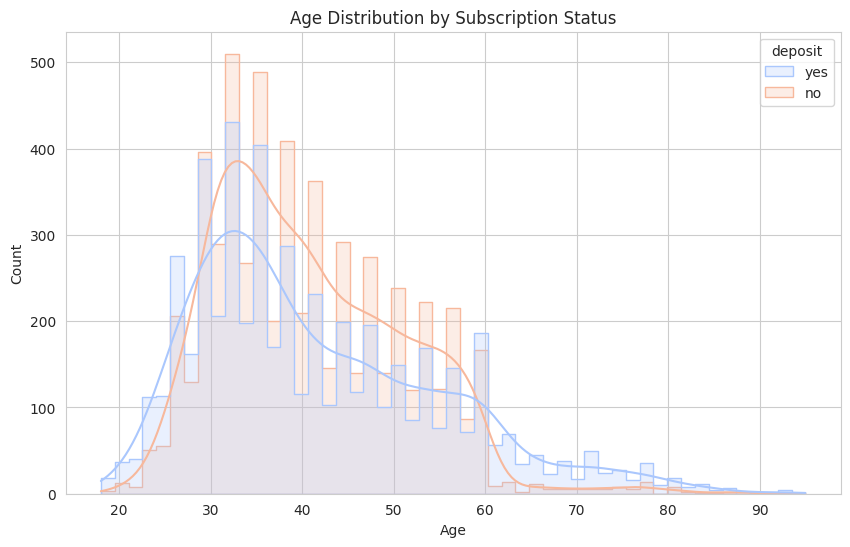

In [20]:
# Age Distribution by Target
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='deposit', kde=True, element='step', palette='coolwarm')
plt.title('Age Distribution by Subscription Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.savefig('images/age_dist.png')
plt.show()

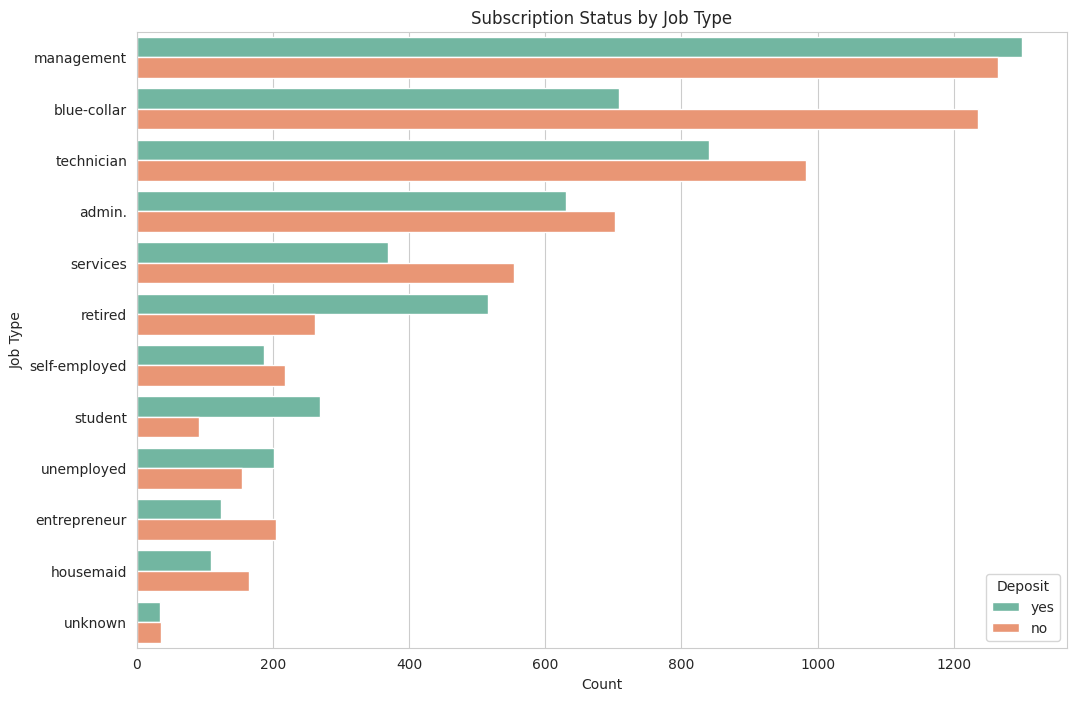

In [21]:
# Job Type vs Subscription
plt.figure(figsize=(12, 8))
job_order = df['job'].value_counts().index
sns.countplot(y='job', hue='deposit', data=df, order=job_order, palette='Set2')
plt.title('Subscription Status by Job Type')
plt.xlabel('Count')
plt.ylabel('Job Type')
plt.legend(title='Deposit', loc='lower right')
plt.savefig('images/job_deposit.png')
plt.show()

/tmp/ipykernel_34892/2392360395.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='deposit', y='balance', data=df, showfliers=False, palette='pastel')


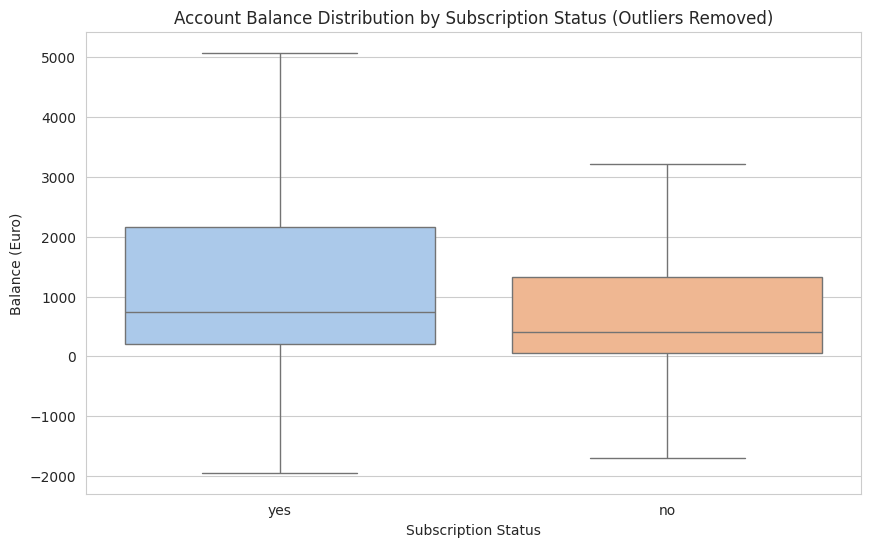

In [22]:
# Balance vs Subscription (Boxplot)
# Limiting balance to remove extreme outliers for better visualization
plt.figure(figsize=(10, 6))
sns.boxplot(x='deposit', y='balance', data=df, showfliers=False, palette='pastel')
plt.title('Account Balance Distribution by Subscription Status (Outliers Removed)')
plt.xlabel('Subscription Status')
plt.ylabel('Balance (Euro)')
plt.savefig('images/balance_deposit.png')
plt.show()

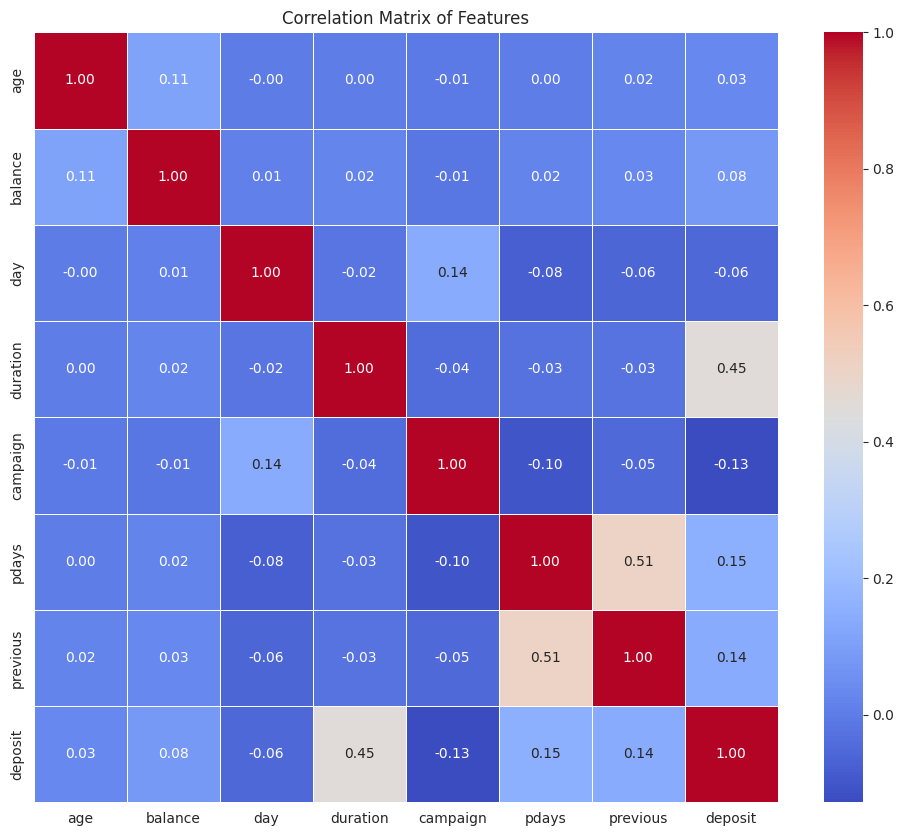

In [23]:
# Correlation Matrix
# Select numerical columns
numeric_df = df.select_dtypes(include=[np.number])
# Also encode target for correlation
df['deposit_code'] = df['deposit'].map({'yes': 1, 'no': 0})
numeric_df['deposit'] = df['deposit_code']

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.savefig('images/correlation.png')
plt.show()

## 4. Key Statistics for Report

In [24]:
print("Total Clients:", len(df))
deposit_counts = df['deposit'].value_counts()
print("Deposit Counts:\n", deposit_counts)
print(f"Subscription Rate: {deposit_counts['yes'] / len(df) * 100:.2f}%")

print("\nMean Age by Deposit Status:")
print(df.groupby('deposit')['age'].mean())

print("\nMean Balance by Deposit Status:")
print(df.groupby('deposit')['balance'].mean())

print("\nTop Correlations with Deposit (Target):")
# Get correlations with the target
target_corr = corr_matrix['deposit'].sort_values(ascending=False)
print(target_corr)

Total Clients: 11162
Deposit Counts:
 deposit
no     5873
yes    5289
Name: count, dtype: int64
Subscription Rate: 47.38%

Mean Age by Deposit Status:
deposit
no     40.837391
yes    41.670070
Name: age, dtype: float64

Mean Balance by Deposit Status:
deposit
no     1280.227141
yes    1804.267915
Name: balance, dtype: float64

Top Correlations with Deposit (Target):
deposit     1.000000
duration    0.451919
pdays       0.151593
previous    0.139867
balance     0.081129
age         0.034901
day        -0.056326
campaign   -0.128081
Name: deposit, dtype: float64
